In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
import scienceplots # 导入SciencePlots

# --- 设置绘图风格 ---
# 使用'science'和'ieee'风格，适用于IEEE出版物
plt.style.use(['science', 'ieee'])
# 设置字体为Times New Roman
plt.rcParams['font.serif'] = ['Times New Roman']
# 设置保存图像的DPI和负号显示
mpl.rcParams['figure.dpi'] = 800
# 允许显示负号
mpl.rcParams['axes.unicode_minus'] = False


# 手动设置科学计数法格式，用于对数坐标轴
import matplotlib.ticker as mtick

def log_tick_formatter(val, pos=None):
    if val == 0:
        return "0"
    exp = np.log10(val)
    # 若为整数指数 -> 主要刻度
    if np.isclose(exp, int(exp), atol=1e-6):
        exp = int(exp)
        if exp == 0:
            return "$1$"
        return rf"$10^{{{exp}}}$"
    # 其它次要刻度不显示
    return ""


In [11]:
# 设置随机种子以确保结果可重现
torch.manual_seed(451)
np.random.seed(451)

# --- 参数设置 ---
Nx = 100    # 输入数据长度
input_data = torch.randn(Nx, 1) # 信号x_k,标准高斯分布


# RLS算法正则化参数
regularization_param = 0.01

# 子系统中噪声尺度参数,网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

# 存储三种N值的结果
N_values = [1, 2, 10, 31, 61]
results = {}

# --- 对每个N值运行实验 ---
for N in N_values:
    print(f"\n处理 N = {N}...")
    
    MSE_array = torch.zeros(NumS)
    Thetas = torch.zeros(N, 1)
    
    best_mse = float('inf')
    best_noise_idx = 0
    best_instantaneous_mse = None
    best_msd_curve = None
    best_predictions = None
    best_weights_evolution = None
    
    # 测试不同噪声尺度
    for i in range(NumS):
        # 为当前噪声尺度重新初始化RLS算法参数
        w = torch.ones(N, 1)
        P = torch.eye(N)
        
        # 生成当前噪声尺度下的噪声张量
        Noise = S[i] * torch.randn(Nx, N)
        
        # 计算阈值系统输出
        input_expanded = input_data.repeat(1, N)
        thetas_expanded = Thetas.T.repeat(Nx, 1)
        
        # 强制符号函数输出±1
        yout = torch.where(input_expanded + Noise - thetas_expanded >= 0,
                           torch.ones_like(input_expanded),
                           -torch.ones_like(input_expanded)).T # N x Nx
        
        # 为当前噪声尺度创建临时数组
        current_instantaneous_mse = torch.zeros(Nx)
        current_msd = torch.zeros(Nx)
        current_y_hat = torch.zeros(Nx)
        current_weights = torch.zeros(Nx, N)
        
        for j in range(Nx):
            y = yout[:, j].reshape(N, 1) # N x 1
            
            # RLS算法更新
            denominator = y.T @ P @ y + regularization_param
            g = (P @ y) / denominator
            
            error = input_data[j, 0] - y.T @ w
            w = w + g * error
            
            P = P - g @ y.T @ P
            
            # 记录数据(对N=31保存详细数据,其他只保存必要数据)
            current_y_hat[j] = (y.T @ w).item()
            
            if N == 31:
                instantaneous_error = input_data[j, 0] - current_y_hat[j]
                current_instantaneous_mse[j] = instantaneous_error ** 2
                current_msd[j] = torch.trace(P)
                current_weights[j] = w.flatten()
        
        # 计算当前噪声尺度下的最终MSE
        final_mse = torch.mean((input_data[:, 0] - current_y_hat)**2)
        MSE_array[i] = final_mse
        
        # 如果当前结果更好,保存为最优结果
        if final_mse < best_mse:
            best_mse = final_mse
            best_noise_idx = i
            if N == 31:
                best_instantaneous_mse = current_instantaneous_mse.clone()
                best_msd_curve = current_msd.clone()
                best_predictions = current_y_hat.clone()
                best_weights_evolution = current_weights.clone()
    
    # 保存结果
    results[N] = {
        'MSE_array': MSE_array,
        'best_mse': best_mse,
        'best_noise_idx': best_noise_idx,
        'best_S': S[best_noise_idx].item()
    }
    
    if N == 31:
        results[N]['instantaneous_mse'] = best_instantaneous_mse
        results[N]['msd_curve'] = best_msd_curve
        results[N]['predictions'] = best_predictions
        results[N]['weights_evolution'] = best_weights_evolution
    
    print(f"N={N}: 最优MSE={best_mse:.6f}, 最优噪声尺度S={S[best_noise_idx]:.3f}")

# 提取数据用于绘图
MSE_LMS2 = results[2]['MSE_array']
best_mse2 = results[2]['best_mse']
best_noise_idx2 = results[2]['best_noise_idx']

MSE_LMS10 = results[10]['MSE_array']
best_mse10 = results[10]['best_mse']
best_noise_idx10 = results[10]['best_noise_idx']

MSE_LMS = results[31]['MSE_array']
best_mse = results[31]['best_mse']
best_noise_idx = results[31]['best_noise_idx']
best_msd_curve = results[31]['msd_curve']
best_predictions = results[31]['predictions']
best_weights_evolution = results[31]['weights_evolution']

MSE_LMS61 = results[61]['MSE_array']
best_mse61 = results[61]['best_mse']
best_noise_idx61 = results[61]['best_noise_idx']


处理 N = 1...
N=1: 最优MSE=0.367801, 最优噪声尺度S=0.010

处理 N = 2...
N=2: 最优MSE=0.321970, 最优噪声尺度S=0.200

处理 N = 10...
N=10: 最优MSE=0.157823, 最优噪声尺度S=0.950

处理 N = 31...
N=31: 最优MSE=0.042423, 最优噪声尺度S=1.650

处理 N = 61...
N=61: 最优MSE=0.006320, 最优噪声尺度S=1.800


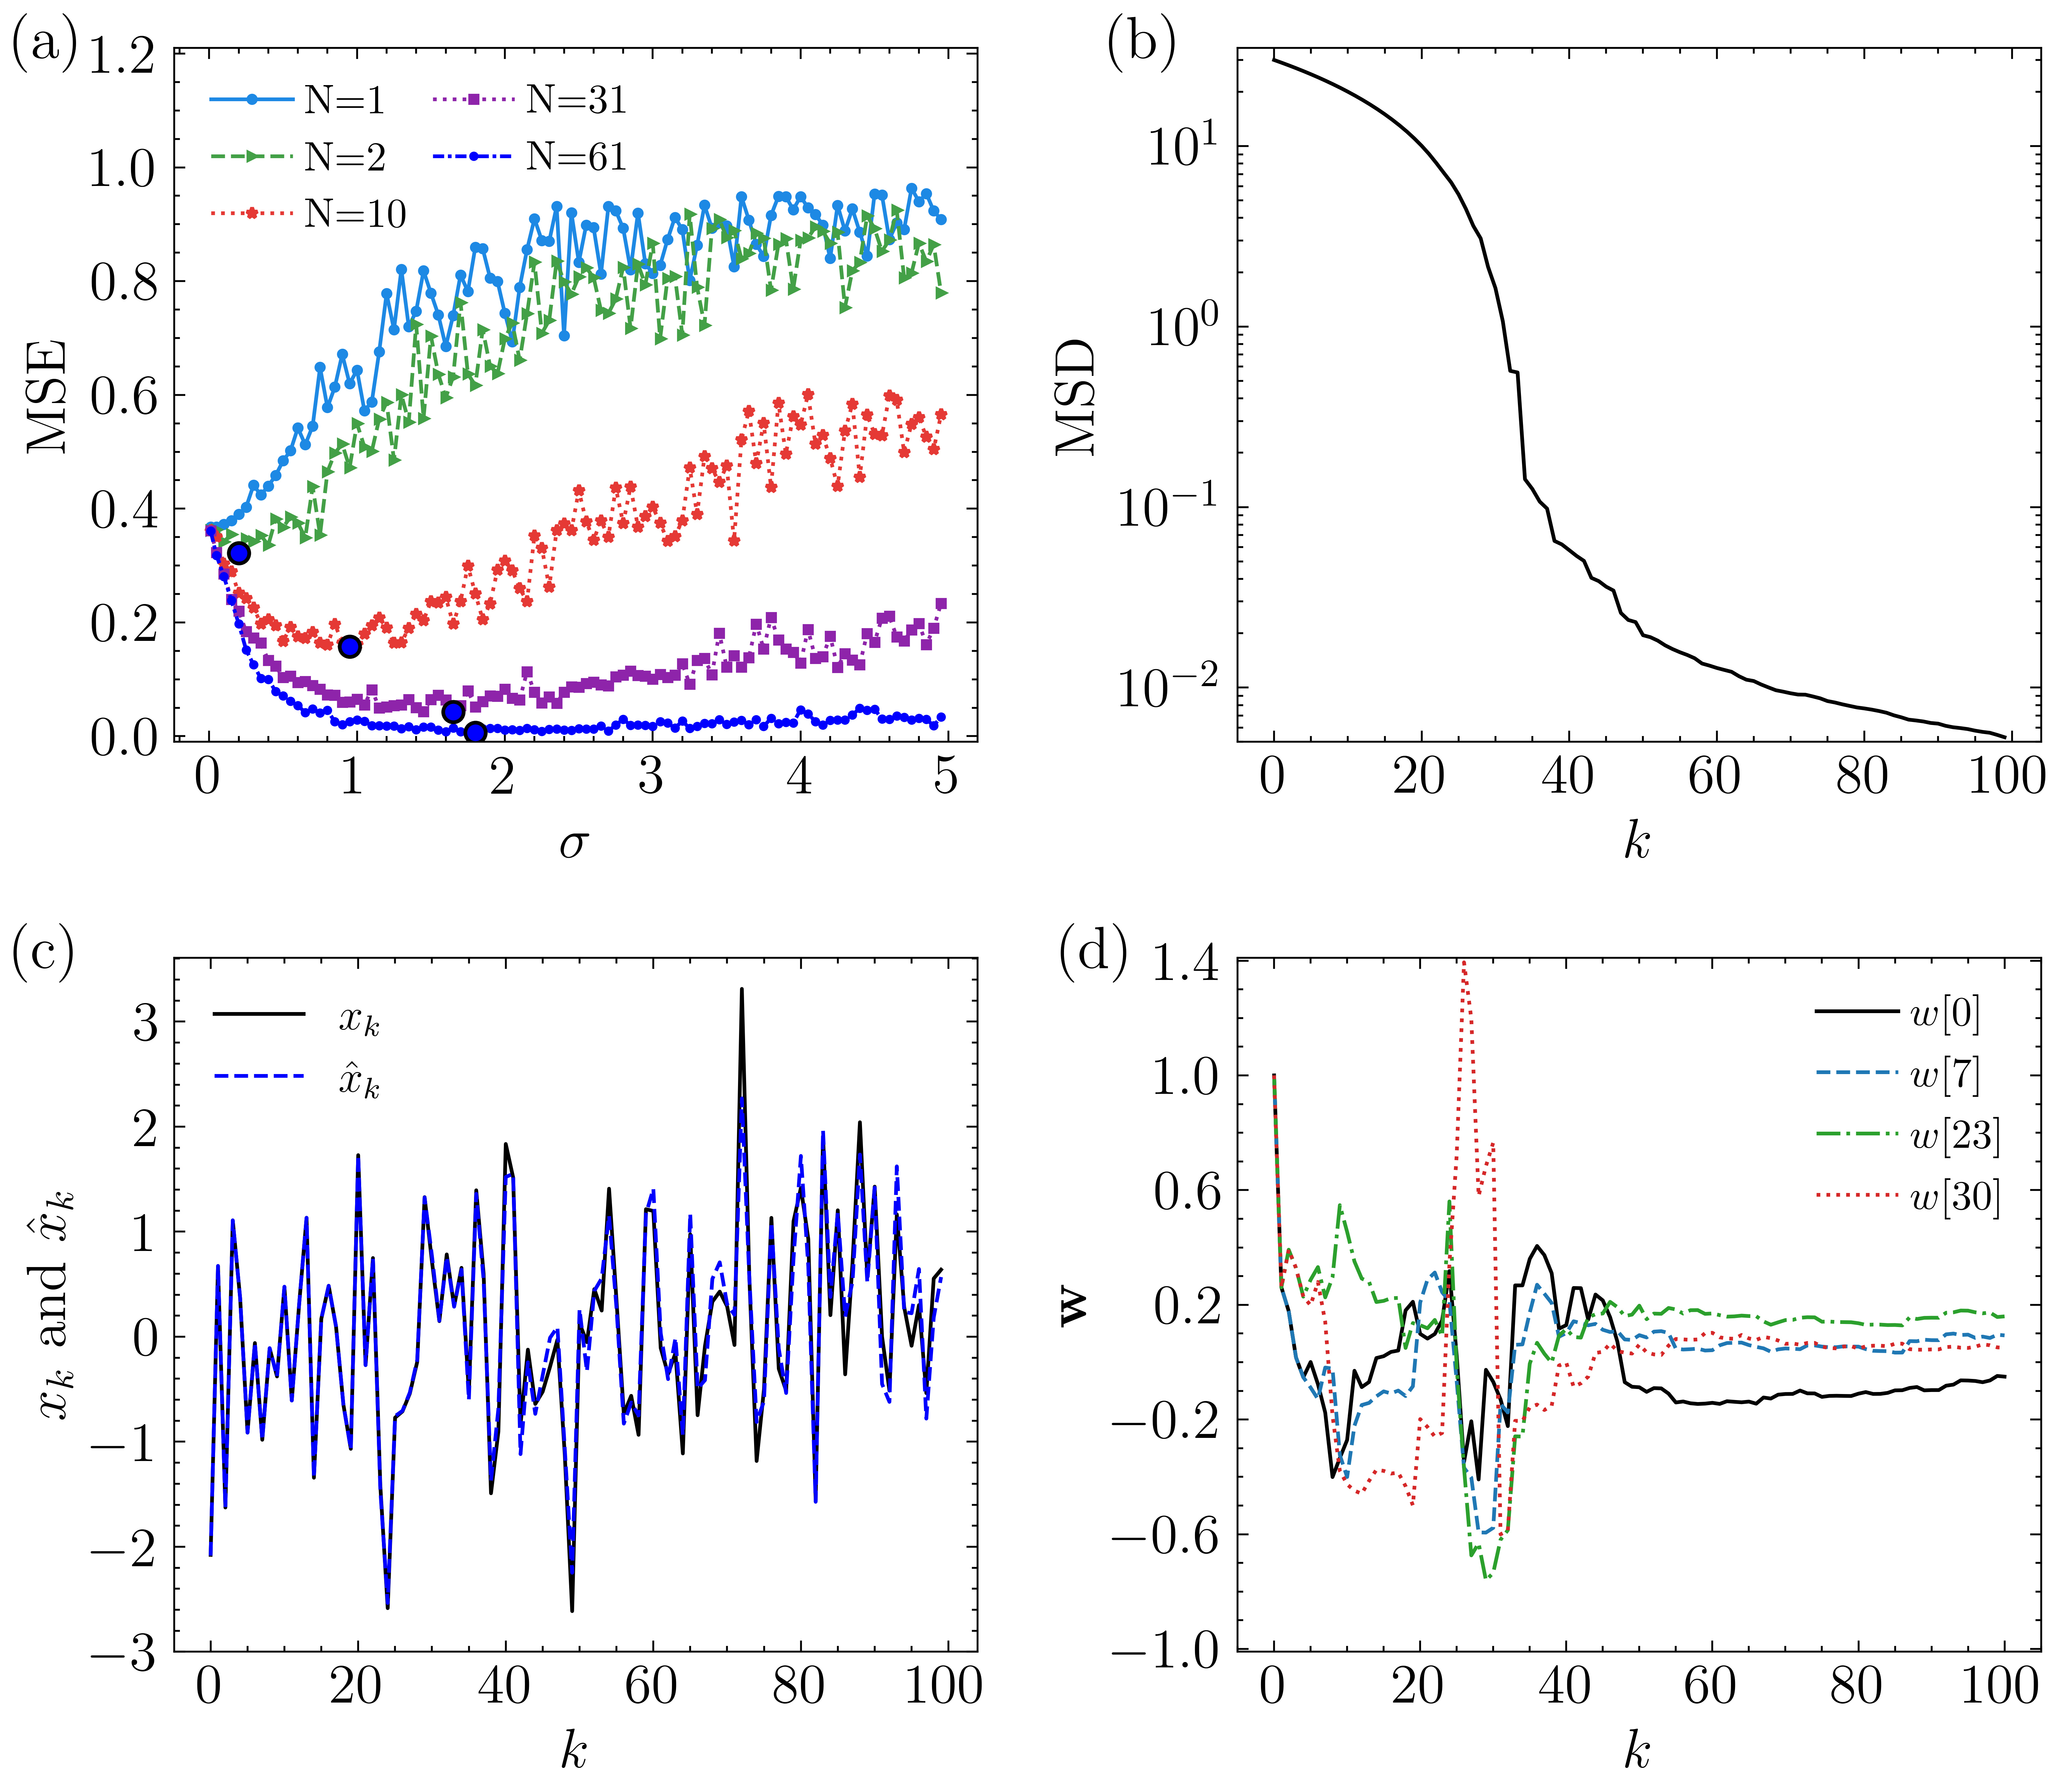


最终结果摘要:
N=  1: 最优MSE=0.367801, 最优噪声尺度S=0.010
N=  2: 最优MSE=0.321970, 最优噪声尺度S=0.200
N= 10: 最优MSE=0.157823, 最优噪声尺度S=0.950
N= 31: 最优MSE=0.042423, 最优噪声尺度S=1.650
N= 61: 最优MSE=0.006320, 最优噪声尺度S=1.800


In [26]:
N = 31  # 用于权重图

# --- 绘图 ---
plt.rcParams.update({
    'font.size': 14,          # 基础字体大小
    'axes.labelsize': 15,      # 坐标轴标签
    'axes.titlesize': 15,      # 子图标题
    'xtick.labelsize': 15,     # x轴刻度
    'ytick.labelsize': 15,     # y轴刻度
    'legend.fontsize': 15,     # 图例
    'figure.titlesize': 15     # 图形标题
})

fig1, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# 子图标签
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# 子图1：MSE vs 噪声尺度 - 修改这里
colors = [
    '#1E88E5',  # 明亮蓝
    '#43A047',  # 鲜绿
    '#E53935',  # 鲜红
    '#8E24AA',  # 紫罗兰
    '#FB8C00'   # 橙黄
]



linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))] 
MSE_LMS1 = results[1]['MSE_array']
MSE_LMS2 = results[2]['MSE_array']

ax = axes[0]
ax.plot(S.numpy(), MSE_LMS1.numpy(), linestyle=linestyles[0], color=colors[0], marker='o', markersize=2, label='N=1')
ax.plot(S.numpy(), MSE_LMS2.numpy(), linestyle=linestyles[1], color=colors[1], marker='>', markersize=2, label='N=2')
ax.plot(S.numpy(), MSE_LMS10.numpy(), linestyle=linestyles[3], color=colors[2], marker='*', markersize=3, label='N=10')
ax.plot(S.numpy(), MSE_LMS.numpy(), linestyle=linestyles[3], color=colors[3], marker='s', markersize=2, label='N=31')
ax.plot(S.numpy(), MSE_LMS61.numpy(), linestyle=linestyles[4], color='blue', marker='.', markersize=3, label='N=61')

# best MSD markers：大一点 + 用相同颜色体系
ax.scatter(S[best_noise_idx2].numpy(), best_mse2.numpy(), color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx10].numpy(), best_mse10.numpy(), color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx].numpy(),   best_mse.numpy(),   color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx61].numpy(), best_mse61.numpy(), color='blue', s=30, zorder=5, edgecolors='black')

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([-0.01,1.21])
ax.set_yticks(np.arange(0,1.21,0.2)) 
ax.set_xticks(np.arange(0,6,1))  
ax.legend(
    loc='upper left',
    #bbox_to_anchor=(0.7, 1.0),
    ncol=2, 
    fontsize = 11,    
    columnspacing=0.6,
    handletextpad=0.3
)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[0], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')


# 子图2：MSD演化(P矩阵的迹)
ax = axes[1]
ax.plot(best_msd_curve.numpy())
ax.set_xlabel(r'$k$')
ax.set_ylabel('MSD')
ax.set_yscale('log')
ax.set_ylim([0.005, 35])
# 指定刻度 + 标签（完全由你控制）
yticks = [1e-2, 1e-1, 1, 10]
labels = [r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
ax.set_yticks(yticks)
ax.set_yticklabels(labels)   # 只这一个，不要再 formatter
ax.set_xticks(np.arange(0,110,20))  
ax.grid(False)
ax.text(-0.16, 1.05, subplot_labels[1], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图3：信号拟合效果对比(前100个点)
ax = axes[2]
sample_range = slice(0, min(100, Nx))
sample_indices = np.arange(len(input_data[sample_range, 0]))
ax.plot(sample_indices, input_data[sample_range, 0].numpy(), label= r'$x_k$')
ax.plot(sample_indices, best_predictions[sample_range].numpy(), color='blue', linestyle='--', label= r'$\hat{x}_k$')
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$')
yticks = [-3.0,-2.0, -1.0, 0, 1.0, 2.0,3.0]
ax.set_yticks(yticks)
ax.set_xticks(np.arange(0,110,20))  
ax.legend(loc='upper left', fontsize = 12)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[2], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图4：权重向量演化
ax = axes[3]
colors = ['k', '#1f77b4', '#2ca02c', '#d62728']
line_styles = ['-', '--', '-.', ':']

N_val = N
weight_indices = [0, N_val//4, 3*N_val//4, N_val-1] if N_val >= 5 else [0, N_val//2, N_val-1] if N_val >= 3 else [0]

for i, idx in enumerate(weight_indices):
    w_series = best_weights_evolution[:, idx].numpy()
    w_series = np.concatenate(([1.0], w_series))   # prepend initial w=1

    ax.plot(w_series,
            label=f'$w[{idx}]$',
            linestyle=line_styles[i % len(line_styles)],
            linewidth=1.0,  
            color=colors[i % len(colors)])

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\mathbf{w}$')
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8))
ax.set_xticks(np.arange(0,110,20))  
ax.legend(
    loc='upper right',
    #bbox_to_anchor=(0.7, 1.0),
    ncol=1, 
    fontsize = 11,    
    columnspacing=0.6,
    handletextpad=0.3
)
ax.set_ylim([-1.01, 1.41])
ax.set_yticks([-1.0,-0.6,-0.2,0.2,0.6,1.0,1.4]) 
ax.grid(False)
ax.text(-0.22, 1.05, subplot_labels[3], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

fig1.tight_layout()
fig1.savefig('D:/IEEE 2025 Adaptive weighted SSR/Fig3.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# 打印最终结果摘要
print("\n" + "="*60)
print("最终结果摘要:")
print("="*60)
for N_val in N_values:
    res = results[N_val]
    print(f"N={N_val:3d}: 最优MSE={res['best_mse']:.6f}, 最优噪声尺度S={res['best_S']:.3f}")
print("="*60)

In [2]:
# 设置随机种子以确保结果可重现
torch.manual_seed(451)
np.random.seed(451)

# --- 参数设置 ---
Nx = 100    # 输入数据长度
input_data = torch.randn(Nx, 1) # 信号x_k,标准高斯分布


# RLS算法正则化参数
regularization_param = 0.01

# 子系统中噪声尺度参数,网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

# 存储三种N值的结果
N_values = [1, 2, 10, 31, 61]
results = {}

# --- 对每个N值运行实验 ---
for N in N_values:
    print(f"\n处理 N = {N}...")
    
    MSE_array = torch.zeros(NumS)
    Thetas = torch.zeros(N, 1)
    
    best_mse = float('inf')
    best_noise_idx = 0
    best_instantaneous_mse = None
    best_msd_curve = None
    best_predictions = None
    best_weights_evolution = None
    
    # 测试不同噪声尺度
    for i in range(NumS):
        # 为当前噪声尺度重新初始化RLS算法参数
            # 注意：w和P现在都是标量
        # 初始权重设为1/N，因为y_k的量级约为sqrt(N)到N
        w = torch.tensor(1.0)  # 标量权系数
        P = torch.tensor(1.0)  # 标量协方差
        
        # 生成当前噪声尺度下的噪声张量
        Noise = S[i] * torch.randn(Nx, N)
        
        # 计算阈值系统输出
        input_expanded = input_data.repeat(1, N)
        thetas_expanded = Thetas.T.repeat(Nx, 1)
        
        # 强制符号函数输出±1
        yout = torch.where(input_expanded + Noise - thetas_expanded >= 0,
                           torch.ones_like(input_expanded),
                           -torch.ones_like(input_expanded)).T # N x Nx
        
        # 为当前噪声尺度创建临时数组
        current_instantaneous_mse = torch.zeros(Nx)
        current_msd = torch.zeros(Nx)
        current_y_hat = torch.zeros(Nx)
        current_weights = torch.zeros(Nx, N)
        
        for j in range(Nx):
            # 计算所有子系统输出的和：y_k = sum_{n=1}^{N} y_{n,k}
            y_k = torch.sum(yout[:, j])  # 标量
        
            # 预测输出（使用上一时刻的权重）：x̂_k = y_k * w_{k-1}
            x_hat = y_k * w
        
            # 误差：e_k = x_k - y_k * w_{k-1}
            error = input_data[j, 0] - x_hat
        
            # RLS算法更新（标量版本）
            # g_k = P_{k-1} * y_k / (y_k^2 * P_{k-1} + δ)
            denominator = y_k**2 * P + regularization_param
            g_k = (P * y_k) / denominator
        
            # 更新权重：w_k = w_{k-1} + g_k * (x_k - y_k * w_{k-1})
            w = w + g_k * error
        
            # 更新协方差：P_k = P_{k-1} - g_k * y_k * P_{k-1}
            P = P - g_k * y_k * P
            
            # 记录数据(对N=31保存详细数据,其他只保存必要数据)
            current_y_hat[j] = (y_k * w).item()
            
            if N == 31:
                instantaneous_error = input_data[j, 0] - current_y_hat[j]
                current_instantaneous_mse[j] = instantaneous_error ** 2
                current_msd[j] = P.item()
                current_weights[j] = w.item()
        
        # 计算当前噪声尺度下的最终MSE
        final_mse = torch.mean((input_data[:, 0] - current_y_hat)**2)
        MSE_array[i] = final_mse
        
        # 如果当前结果更好,保存为最优结果
        if final_mse < best_mse:
            best_mse = final_mse
            best_noise_idx = i
            if N == 31:
                best_instantaneous_mse = current_instantaneous_mse.clone()
                best_msd_curve = current_msd.clone()
                best_predictions = current_y_hat.clone()
                best_weights_evolution = current_weights.clone()
    
    # 保存结果
    results[N] = {
        'MSE_array': MSE_array,
        'best_mse': best_mse,
        'best_noise_idx': best_noise_idx,
        'best_S': S[best_noise_idx].item()
    }
    
    if N == 31:
        results[N]['instantaneous_mse'] = best_instantaneous_mse
        results[N]['msd_curve'] = best_msd_curve
        results[N]['predictions'] = best_predictions
        results[N]['weights_evolution'] = best_weights_evolution
    
    print(f"N={N}: 最优MSE={best_mse:.6f}, 最优噪声尺度S={S[best_noise_idx]:.3f}")

# 提取数据用于绘图
MSE_LMS2 = results[2]['MSE_array']
best_mse2 = results[2]['best_mse']
best_noise_idx2 = results[2]['best_noise_idx']

MSE_LMS10 = results[10]['MSE_array']
best_mse10 = results[10]['best_mse']
best_noise_idx10 = results[10]['best_noise_idx']

MSE_LMS = results[31]['MSE_array']
best_mse = results[31]['best_mse']
best_noise_idx = results[31]['best_noise_idx']
best_msd_curve = results[31]['msd_curve']
best_predictions = results[31]['predictions']
best_weights_evolution = results[31]['weights_evolution']

MSE_LMS61 = results[61]['MSE_array']
best_mse61 = results[61]['best_mse']
best_noise_idx61 = results[61]['best_noise_idx']


处理 N = 1...
N=1: 最优MSE=0.367801, 最优噪声尺度S=0.010

处理 N = 2...
N=2: 最优MSE=0.323392, 最优噪声尺度S=0.200

处理 N = 10...
N=10: 最优MSE=0.190714, 最优噪声尺度S=0.500

处理 N = 31...
N=31: 最优MSE=0.103825, 最优噪声尺度S=1.000

处理 N = 61...
N=61: 最优MSE=0.073959, 最优噪声尺度S=1.400


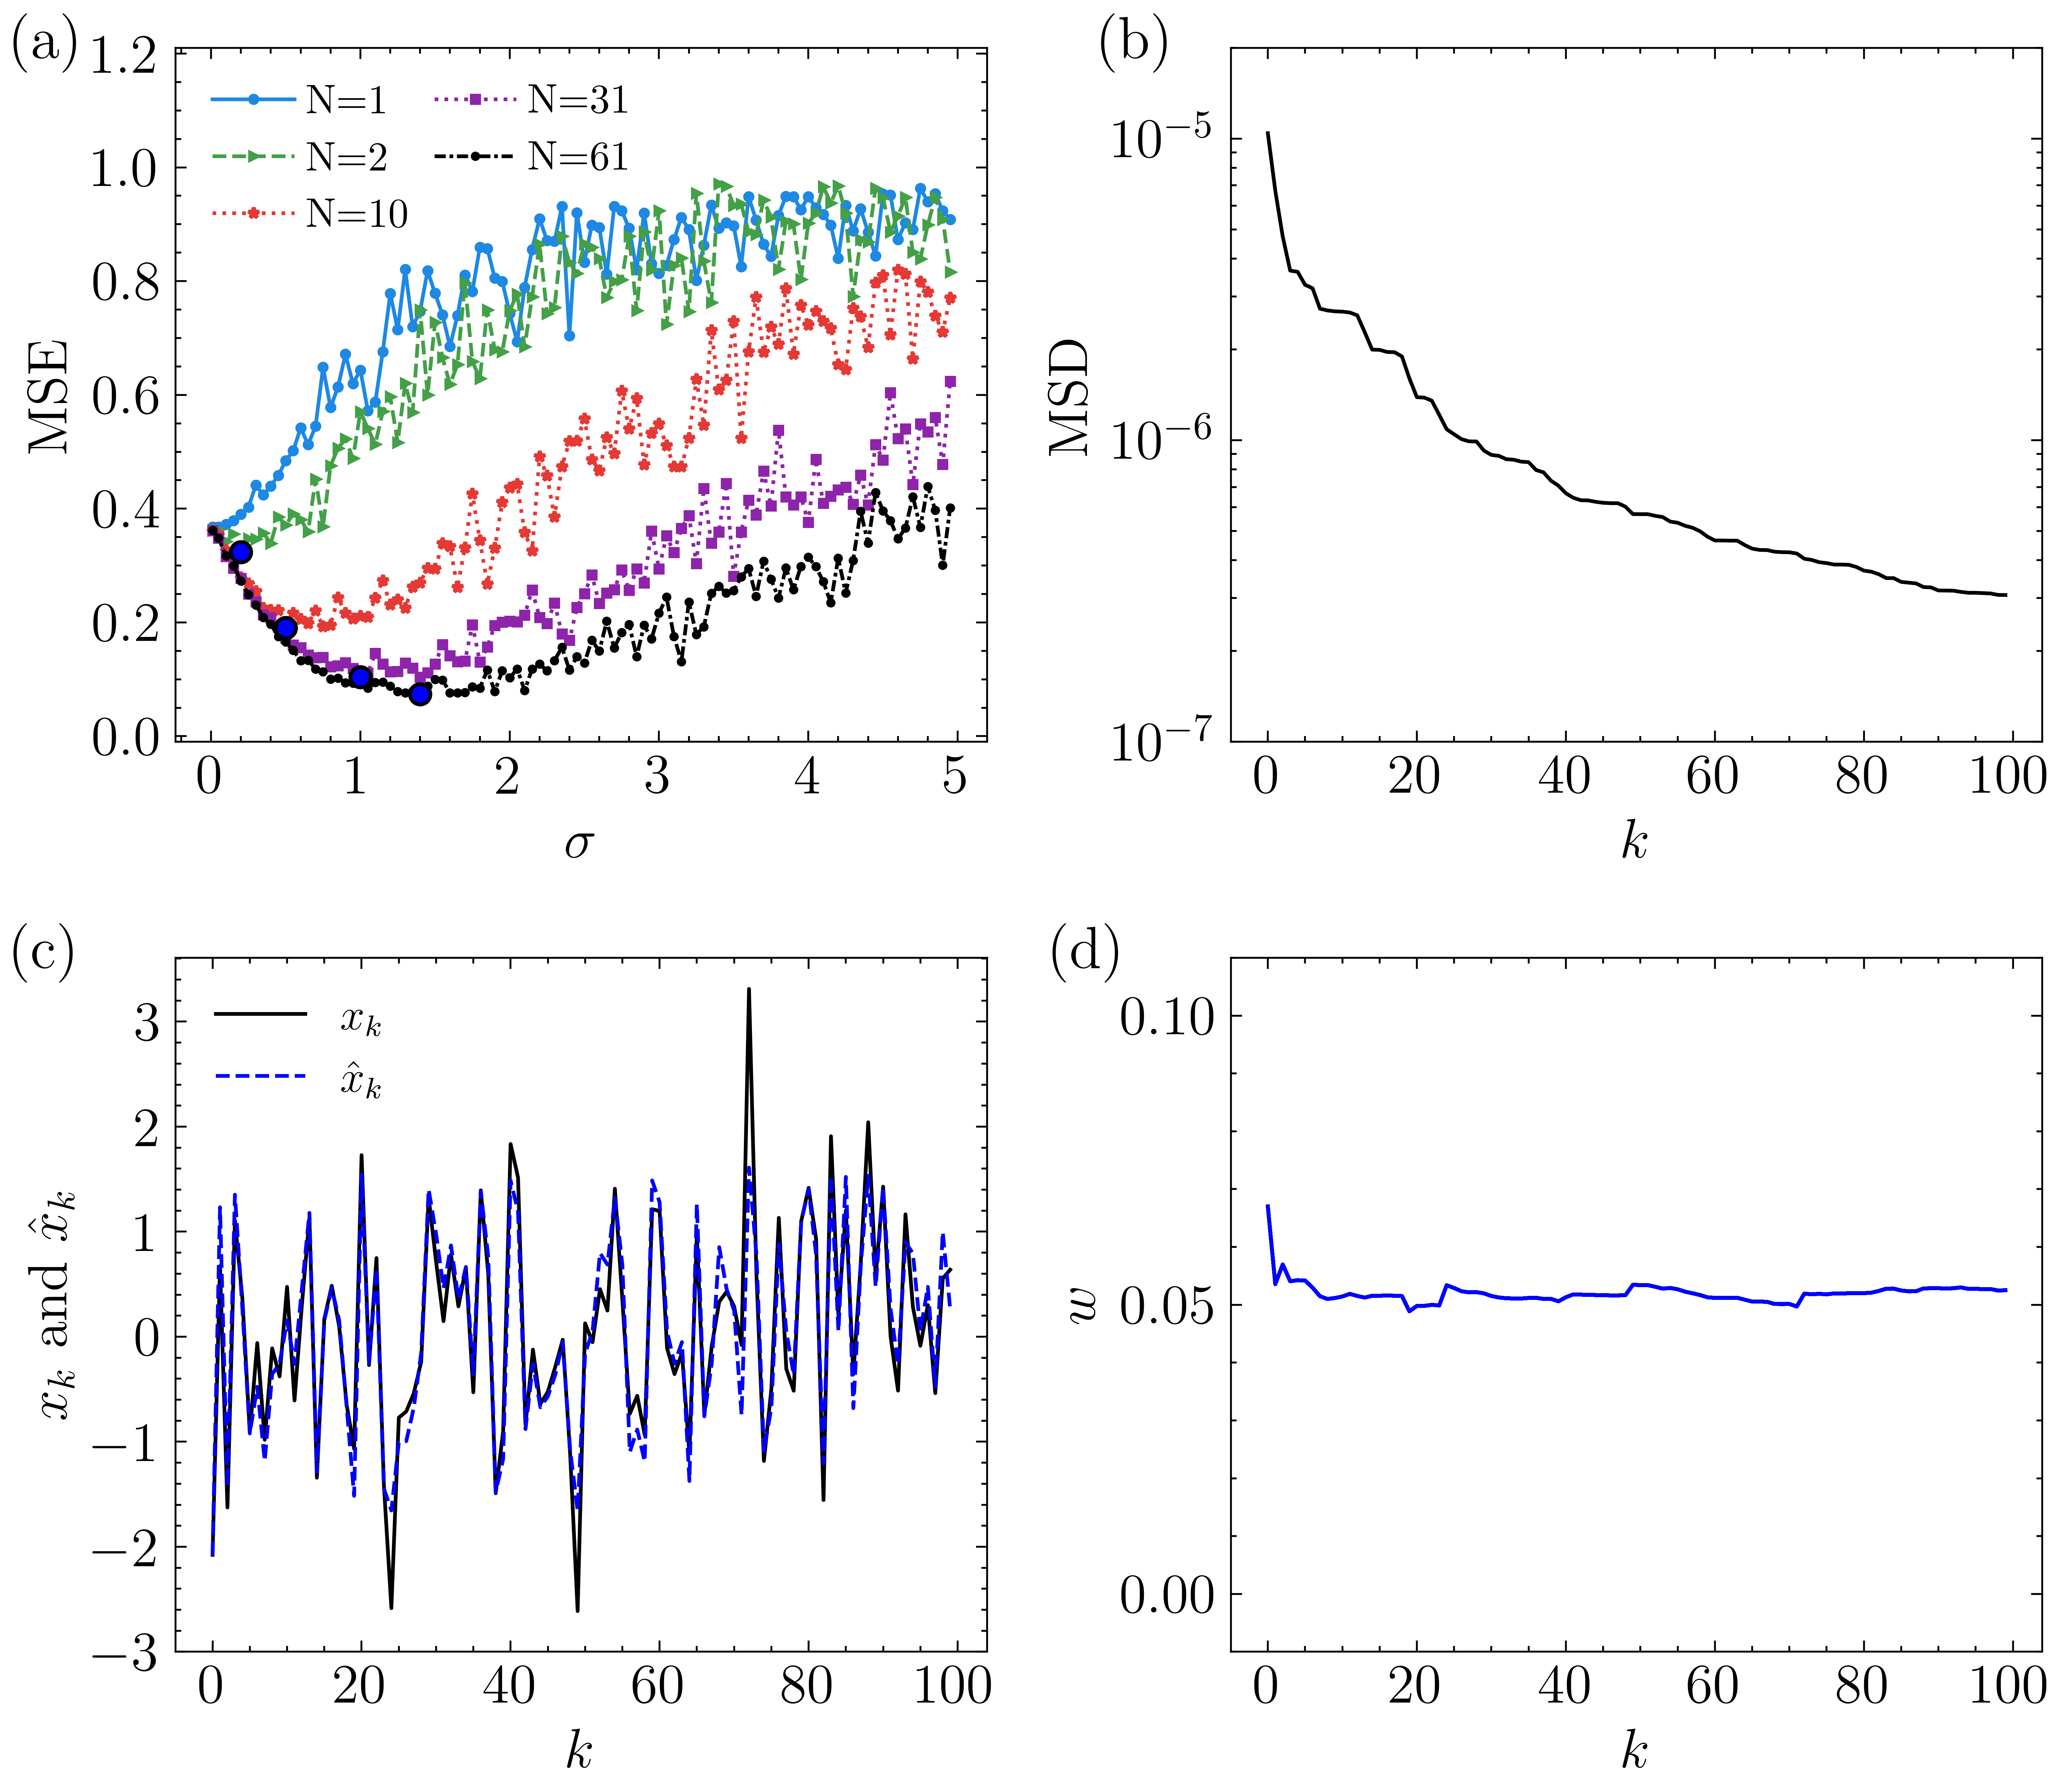


最终结果摘要:
N=  1: 最优MSE=0.367801, 最优噪声尺度S=0.010
N=  2: 最优MSE=0.323392, 最优噪声尺度S=0.200
N= 10: 最优MSE=0.190714, 最优噪声尺度S=0.500
N= 31: 最优MSE=0.103825, 最优噪声尺度S=1.000
N= 61: 最优MSE=0.073959, 最优噪声尺度S=1.400


In [3]:
N = 31  # 用于权重图

# --- 绘图 ---
plt.rcParams.update({
    'font.size': 14,          # 基础字体大小
    'axes.labelsize': 15,      # 坐标轴标签
    'axes.titlesize': 15,      # 子图标题
    'xtick.labelsize': 15,     # x轴刻度
    'ytick.labelsize': 15,     # y轴刻度
    'legend.fontsize': 15,     # 图例
    'figure.titlesize': 15     # 图形标题
})

fig1, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# 子图标签
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# 子图1：MSE vs 噪声尺度 - 修改这里
colors = [
    '#1E88E5',  # 明亮蓝
    '#43A047',  # 鲜绿
    '#E53935',  # 鲜红
    '#8E24AA',  # 紫罗兰
    '#FB8C00'   # 橙黄
]



linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))] 
MSE_LMS1 = results[1]['MSE_array']
MSE_LMS2 = results[2]['MSE_array']

ax = axes[0]
ax.plot(S.numpy(), MSE_LMS1.numpy(), linestyle=linestyles[0], color=colors[0], marker='o', markersize=2, label='N=1')
ax.plot(S.numpy(), MSE_LMS2.numpy(), linestyle=linestyles[1], color=colors[1], marker='>', markersize=2, label='N=2')
ax.plot(S.numpy(), MSE_LMS10.numpy(), linestyle=linestyles[3], color=colors[2], marker='*', markersize=3, label='N=10')
ax.plot(S.numpy(), MSE_LMS.numpy(), linestyle=linestyles[3], color=colors[3], marker='s', markersize=2, label='N=31')
ax.plot(S.numpy(), MSE_LMS61.numpy(), linestyle=linestyles[4], color='k', marker='.', markersize=3, label='N=61')

# best MSD markers：大一点 + 用相同颜色体系
ax.scatter(S[best_noise_idx2].numpy(), best_mse2.numpy(), color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx10].numpy(), best_mse10.numpy(), color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx].numpy(),   best_mse.numpy(),   color='blue', s=30, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx61].numpy(), best_mse61.numpy(), color='blue', s=30, zorder=5, edgecolors='black')

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([-0.01,1.21])
ax.set_yticks(np.arange(0,1.21,0.2)) 
ax.set_xticks(np.arange(0,6,1))  
ax.legend(
    loc='upper left',
    #bbox_to_anchor=(0.7, 1.0),
    ncol=2, 
    fontsize = 11,    
    columnspacing=0.6,
    handletextpad=0.3
)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[0], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')


# 子图2：MSD演化(P矩阵的迹)
ax = axes[1]
ax.plot(best_msd_curve.numpy())
ax.set_xlabel(r'$k$')
ax.set_ylabel('MSD')
ax.set_yscale('log')

# 数据范围在 [3e-7, 1e-5]，重新设置合理范围
ax.set_ylim(3e-7, 2e-5)

# 重新设置刻度（覆盖数据区间）
yticks = [1e-7, 1e-6, 1e-5]
labels = [r'$10^{-7}$', r'$10^{-6}$', r'$10^{-5}$']

ax.set_yticks(yticks)
ax.set_yticklabels(labels) 

ax.set_xticks(np.arange(0,110,20))  
ax.grid(False)

ax.text(-0.16, 1.05, subplot_labels[1], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')


# 子图3：信号拟合效果对比(前100个点)
ax = axes[2]
sample_range = slice(0, min(100, Nx))
sample_indices = np.arange(len(input_data[sample_range, 0]))
ax.plot(sample_indices, input_data[sample_range, 0].numpy(), label= r'$x_k$')
ax.plot(sample_indices, best_predictions[sample_range].numpy(), color='blue', linestyle='--', label= r'$\hat{x}_k$')
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$')
yticks = [-3.0,-2.0, -1.0, 0, 1.0, 2.0,3.0]
ax.set_yticks(yticks)
ax.set_xticks(np.arange(0,110,20))  
ax.legend(loc='upper left', fontsize = 12)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[2], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图4：权重向量演化
ax = axes[3]

N_val = N

ax.plot(best_weights_evolution, linestyle='-', linewidth=1.0, color='blue') 
ax.set_xlabel(r'$k$') 
ax.set_ylabel(r'$w$') 
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8)) 
ax.set_xticks(np.arange(0,110,20)) 
ax.set_ylim([-0.01, 0.11]) 
ax.set_yticks([0.0,0.05,0.1]) 
ax.grid(False) 
ax.text(-0.22, 1.05, subplot_labels[3], transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

fig1.tight_layout()
fig1.savefig('D:/IEEE 2025 Adaptive weighted SSR/Fig6.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# 打印最终结果摘要
print("\n" + "="*60)
print("最终结果摘要:")
print("="*60)
for N_val in N_values:
    res = results[N_val]
    print(f"N={N_val:3d}: 最优MSE={res['best_mse']:.6f}, 最优噪声尺度S={res['best_S']:.3f}")
print("="*60)

In [14]:
print(best_msd_curve.numpy())

[1.0430813e-05 6.7217939e-06 4.7332842e-06 3.6527038e-06 3.6196500e-06
 3.2768642e-06 3.1921365e-06 2.7309734e-06 2.6949108e-06 2.6768760e-06
 2.6704424e-06 2.6527325e-06 2.5969318e-06 2.2832626e-06 1.9981226e-06
 1.9945358e-06 1.9628249e-06 1.9593635e-06 1.8965623e-06 1.6041843e-06
 1.3899124e-06 1.3850995e-06 1.3534184e-06 1.2151114e-06 1.0880566e-06
 1.0469342e-06 1.0088071e-06 9.9189640e-07 9.9101169e-07 9.2424017e-07
 8.9439851e-07 8.8796554e-07 8.6574852e-07 8.6209138e-07 8.4971163e-07
 8.4618847e-07 7.9702244e-07 7.8298120e-07 7.3460819e-07 7.0712861e-07
 6.6743650e-07 6.4467474e-07 6.3288343e-07 6.3188367e-07 6.2520718e-07
 6.2051299e-07 6.1863204e-07 6.1859379e-07 6.0216666e-07 5.6922653e-07
 5.6893504e-07 5.6890269e-07 5.6171257e-07 5.5643039e-07 5.3772982e-07
 5.3288716e-07 5.2065167e-07 5.1293364e-07 4.9938330e-07 4.7925545e-07
 4.6531758e-07 4.6529593e-07 4.6475532e-07 4.6473372e-07 4.4950491e-07
 4.3722159e-07 4.3296234e-07 4.3249420e-07 4.2715516e-07 4.2568232e-07
 4.252

Testing noise scale S = 0.010
  → New best result! MSE = 8.765860
Testing noise scale S = 0.050
  → New best result! MSE = 8.735397
Testing noise scale S = 0.100
  → New best result! MSE = 8.720332
Testing noise scale S = 0.150
  → New best result! MSE = 8.703601
Testing noise scale S = 0.200
  → New best result! MSE = 8.673480
Testing noise scale S = 0.250
  → New best result! MSE = 8.659837
Testing noise scale S = 0.300
  → New best result! MSE = 8.646366
Testing noise scale S = 0.350
  → New best result! MSE = 8.620979
Testing noise scale S = 0.400
  → New best result! MSE = 8.614269
Testing noise scale S = 0.450
  → New best result! MSE = 8.596874
Testing noise scale S = 0.500
  → New best result! MSE = 8.586965
Testing noise scale S = 0.550
  → MSE = 8.588655
Testing noise scale S = 0.600
  → New best result! MSE = 8.557457
Testing noise scale S = 0.650
  → MSE = 8.560475
Testing noise scale S = 0.700
  → New best result! MSE = 8.541647
Testing noise scale S = 0.750
  → New best r

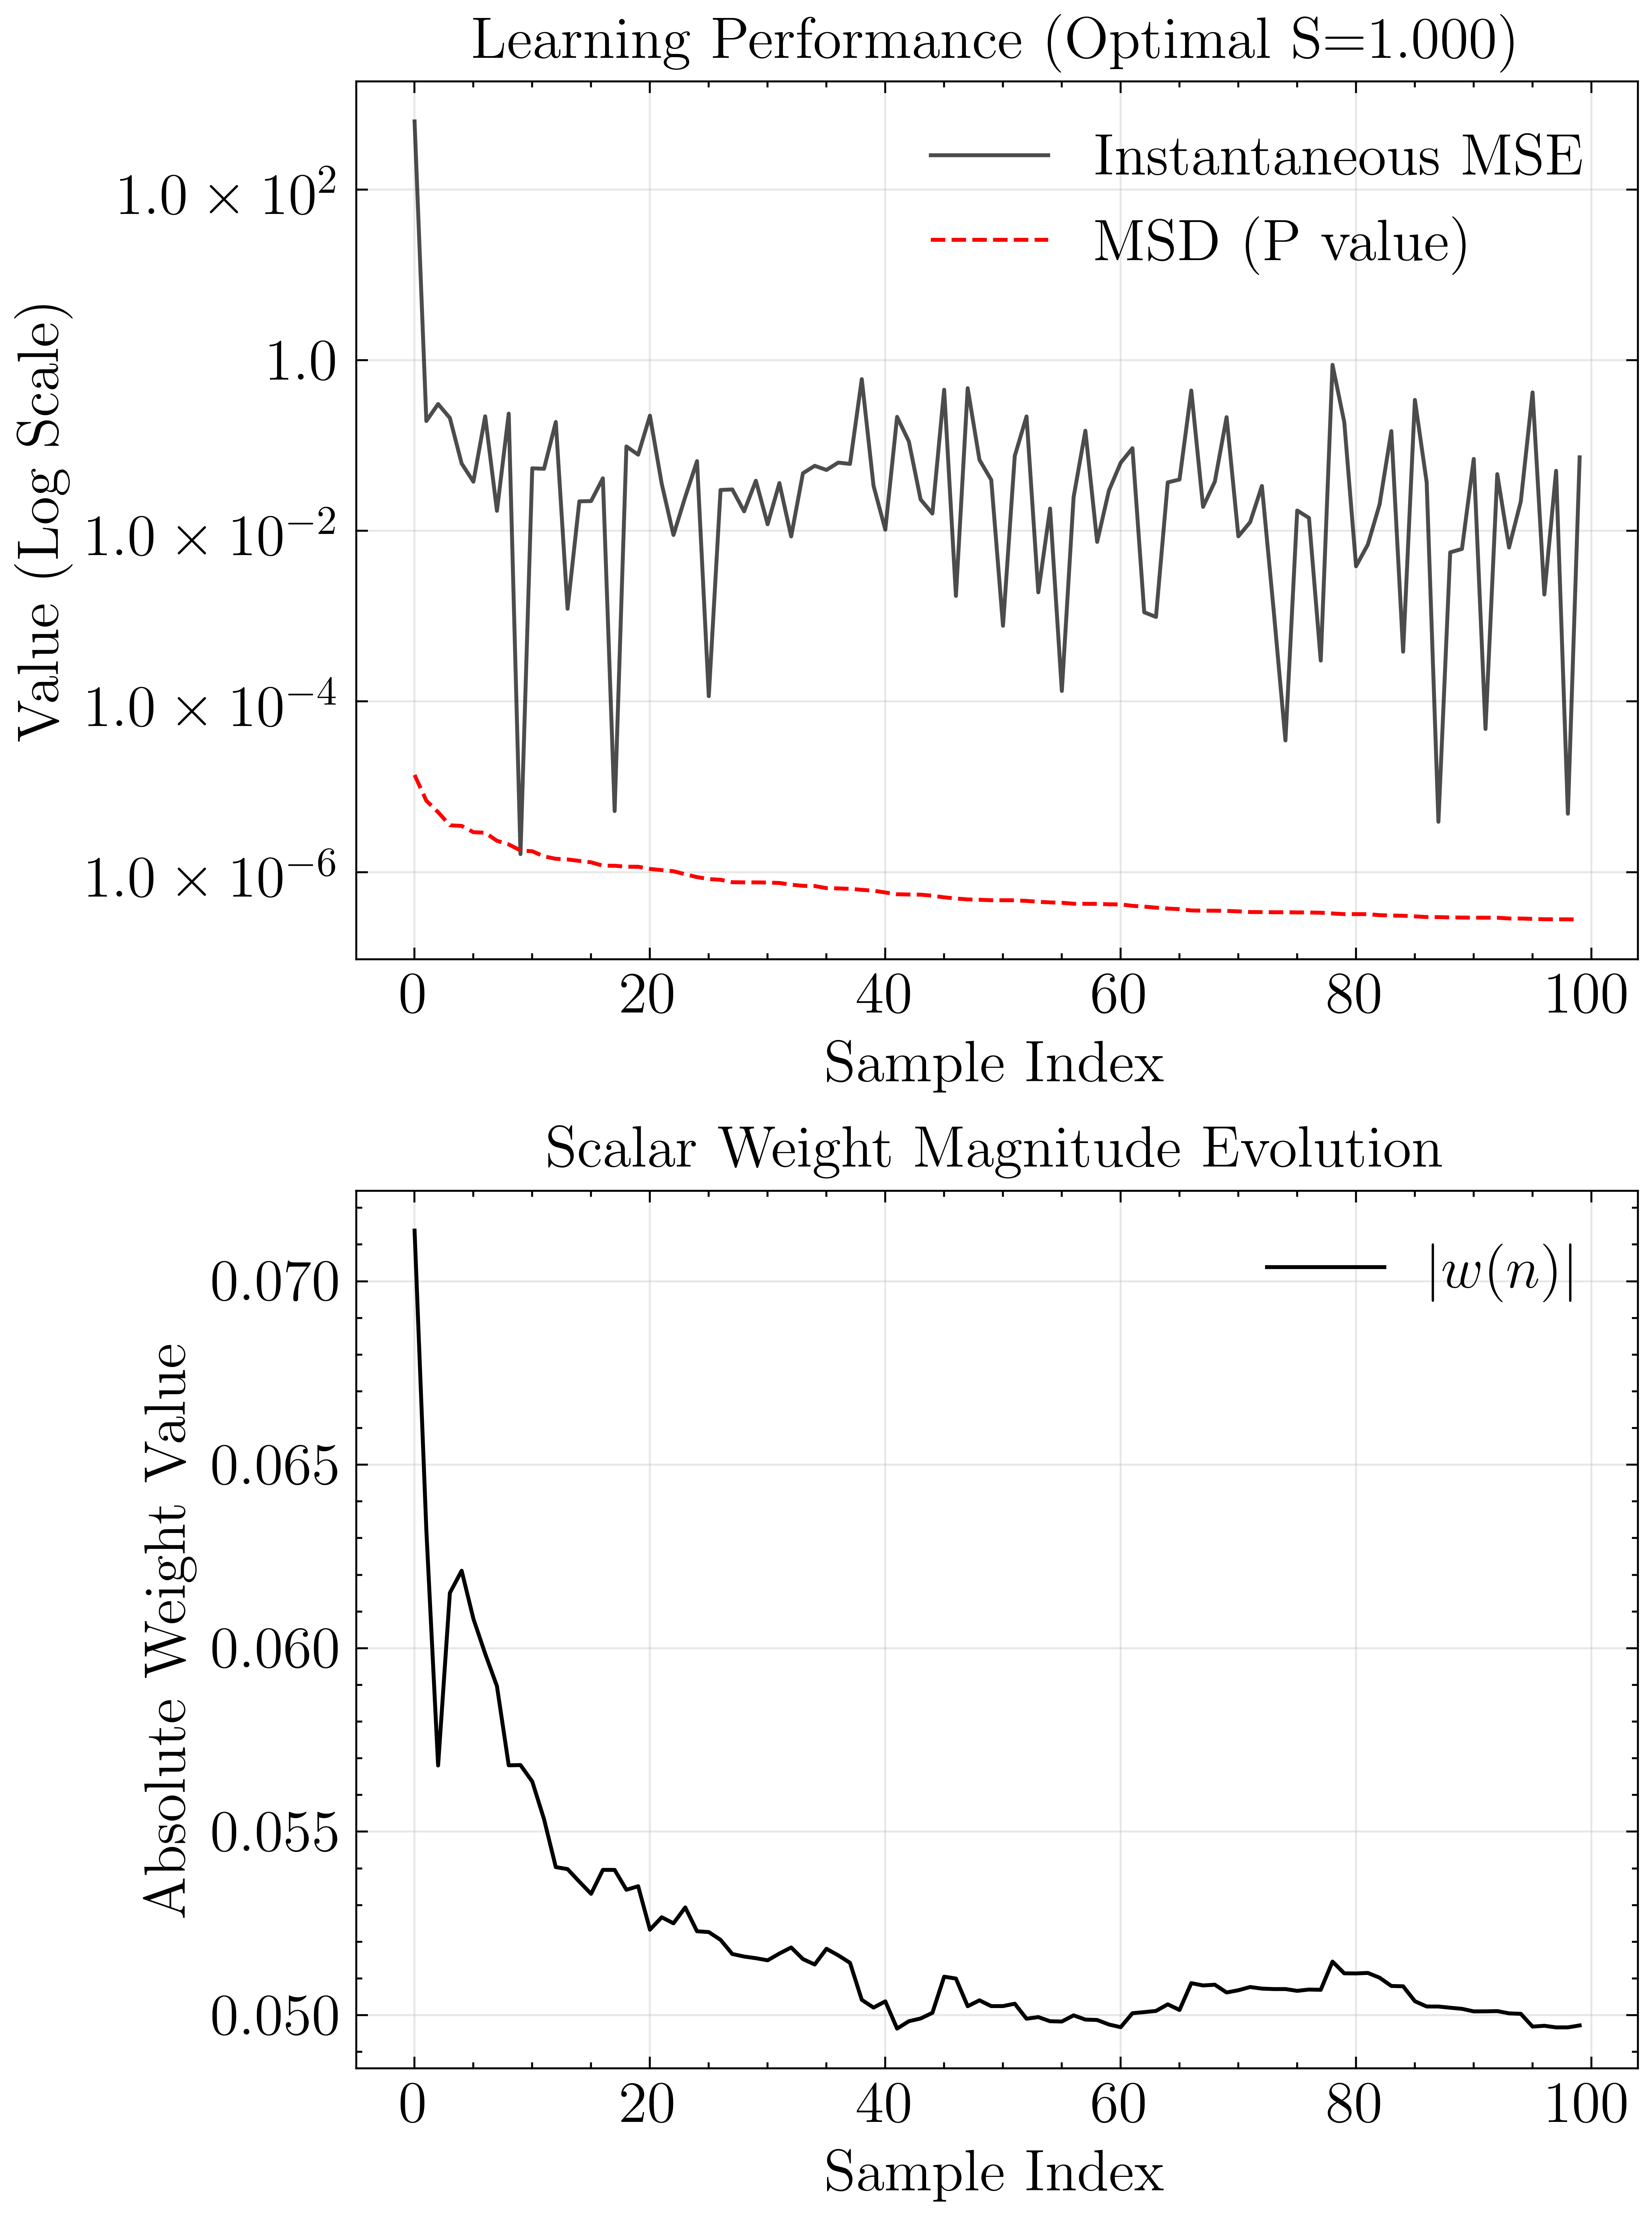

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
import scienceplots # 导入SciencePlots

# --- 设置绘图风格 ---
# 使用'science'和'ieee'风格，适用于IEEE出版物
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
# 设置保存图像的DPI和负号显示
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可重现
torch.manual_seed(42)
np.random.seed(42)


# 手动设置科学计数法格式，用于对数坐标轴
def custom_formatter(x, pos):
    """自定义坐标轴刻度格式化函数，用于科学计数法显示"""
    if x == 0:
        return '0'
    try:
        exp = int(np.floor(np.log10(abs(x))))
        mantissa = x / (10**exp)
        if exp == 0:
            return f'{mantissa:.1f}'
        else:
            # 使用LaTeX格式渲染科学计数法
            return f'${mantissa:.1f} \\times 10^{{{exp}}}$'
    except (ValueError, OverflowError):
        return str(x)

# 设置随机种子以确保结果可重现
torch.manual_seed(42)
np.random.seed(42)

# --- 参数设置 ---
N = 31      # 子系统并联数目
Nx = 100    # 输入数据长度
input_data = torch.randn(Nx, 1) # 信号x_k，标准高斯分布

# RLS算法正则化参数
delta = 0.01  # 正则化参数δ

# 子系统中噪声尺度参数，网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 1.25, 0.05)])
NumS = len(S)

# --- 初始化 ---
MSE_LMS = torch.zeros(NumS)
Theta = 0.0  # 所有子系统共用的阈值

# 用于保存最优噪声尺度下的学习曲线
best_mse = float('inf')
best_noise_idx = 0
best_instantaneous_mse = None
best_msd_curve = None
best_predictions = None
best_weights_evolution = None

# --- 主循环：测试不同噪声尺度 ---
for i in range(NumS):
    print(f"Testing noise scale S = {S[i]:.3f}")
    
    # 为当前噪声尺度重新初始化RLS算法参数
    # 注意：w和P现在都是标量
    # 初始权重设为1/N，因为y_k的量级约为sqrt(N)到N
    w = torch.tensor(1.0)  # 标量权系数
    P = torch.tensor(1.0)  # 标量协方差
    
    # 生成当前噪声尺度下的噪声张量
    Noise = S[i] * torch.randn(Nx, N)
    
    # 计算阈值系统输出
    input_expanded = input_data.repeat(1, N)
    
    # 强制符号函数输出±1
    yout = torch.where(input_expanded + Noise - Theta >= 0,
                      torch.ones_like(input_expanded),
                      -torch.ones_like(input_expanded)).T # N x Nx
    
    # 为当前噪声尺度创建临时数组
    current_instantaneous_mse = torch.zeros(Nx)
    current_msd = torch.zeros(Nx)
    current_y_hat = torch.zeros(Nx)
    current_weights = torch.zeros(Nx)
    
    for j in range(Nx):
        # 计算所有子系统输出的和：y_k = sum_{n=1}^{N} y_{n,k}
        y_k = torch.sum(yout[:, j])  # 标量
        
        # 预测输出（使用上一时刻的权重）：x̂_k = y_k * w_{k-1}
        x_hat = y_k * w
        
        # 误差：e_k = x_k - y_k * w_{k-1}
        error = input_data[j, 0] - x_hat
        
        # RLS算法更新（标量版本）
        # g_k = P_{k-1} * y_k / (y_k^2 * P_{k-1} + δ)
        denominator = y_k**2 * P + delta
        g_k = (P * y_k) / denominator
        
        # 更新权重：w_k = w_{k-1} + g_k * (x_k - y_k * w_{k-1})
        w = w + g_k * error
        
        # 更新协方差：P_k = P_{k-1} - g_k * y_k * P_{k-1}
        P = P - g_k * y_k * P
        
        # 记录数据
        current_y_hat[j] = x_hat.item()
        instantaneous_error = input_data[j, 0] - x_hat
        current_instantaneous_mse[j] = instantaneous_error ** 2
        current_msd[j] = P.item()  # P现在是标量
        current_weights[j] = w.item()
        
    # 计算当前噪声尺度下的最终MSE
    final_mse = torch.mean((input_data[:, 0] - current_y_hat)**2)
    MSE_LMS[i] = final_mse
    
    # 如果当前结果更好，保存为最优结果
    if final_mse < best_mse:
        best_mse = final_mse
        best_noise_idx = i
        best_instantaneous_mse = current_instantaneous_mse.clone()
        best_msd_curve = current_msd.clone()
        best_predictions = current_y_hat.clone()
        best_weights_evolution = current_weights.clone()
        print(f"  → New best result! MSE = {final_mse:.6f}")
    else:
        print(f"  → MSE = {final_mse:.6f}")

# ===============================
# 详细绘图分析 (使用SciencePlots IEEE风格)
# ===============================

# --- 第一个图形窗口：RLS算法性能分析（2×3子图布局）---
fig1, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten() # 将2x3的axes数组扁平化，方便索引

# 子图1：MSE vs 噪声尺度
ax = axes[0]
ax.plot(S.numpy(), MSE_LMS.numpy(), marker='o', markersize=3, label='MSE')
ax.axvline(x=S[best_noise_idx].item(), color='r', linestyle='--',
           label=f'Optimal: S={S[best_noise_idx]:.3f}')
ax.scatter(S[best_noise_idx].numpy(), best_mse.numpy(), color='red', s=40, zorder=5, edgecolors='k')
ax.set_xlabel('Noise Scale Parameter (S)')
ax.set_ylabel('Mean Square Error (MSE)')
ax.set_title('MSE vs Noise Scale')
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：瞬时MSE演化（最优噪声尺度下）
ax = axes[1]
ax.plot(best_instantaneous_mse.numpy(), alpha=0.7, label='Instantaneous')
window_size = max(5, Nx//20)
if Nx >= window_size:
    moving_avg = np.convolve(best_instantaneous_mse.numpy(), np.ones(window_size)/window_size, mode='valid')
    ax.plot(range(window_size-1, Nx), moving_avg,
            label=f'Moving Avg (win={window_size})')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Instantaneous MSE')
ax.set_title(f'Instantaneous MSE (S={S[best_noise_idx]:.3f})')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
ax.legend()
ax.grid(True, alpha=0.3)


# 子图3：MSD演化（P的值）
ax = axes[2]
ax.plot(best_msd_curve.numpy())
ax.set_xlabel('Sample Index')
ax.set_ylabel('MSD (P value)')
ax.set_title('Mean Square Deviation Evolution')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
ax.grid(True, alpha=0.3)

# 子图4：信号拟合效果对比（前50个点）
ax = axes[3]
sample_range = slice(0, min(50, Nx))
sample_indices = np.arange(len(input_data[sample_range, 0]))
ax.plot(sample_indices, input_data[sample_range, 0].numpy(), label='True Input Signal')
ax.plot(sample_indices, best_predictions[sample_range].numpy(), linestyle='--', label='RLS Prediction')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Signal Amplitude')
ax.set_title('Signal Fitting (First 50 points)')
ax.legend()
ax.grid(True, alpha=0.3)

# 子图5：权重标量演化
ax = axes[4]
ax.plot(best_weights_evolution.numpy(), label='w (scalar weight)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Weight Value')
ax.set_title('Scalar Weight Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# 子图6：预测误差分析
ax = axes[5]
prediction_error = (input_data[:, 0] - best_predictions).numpy()
ax.plot(prediction_error, alpha=0.8)
error_std = np.std(prediction_error)
ax.axhline(y=error_std, color='r', linestyle='--', alpha=0.7, label=rf'+1$\sigma$ = {error_std:.3f}')
ax.axhline(y=-error_std, color='r', linestyle='--', alpha=0.7, label=rf'-1$\sigma$ = {-error_std:.3f}')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Prediction Error')
ax.set_title('Prediction Error Sequence')
ax.legend()
ax.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig('rls_identical_subsystems_analysis.png', dpi=800, bbox_inches='tight')


# --- 第二个图形窗口：详细信号分析（2×1布局）---
fig2, axes2 = plt.subplots(2, 1, figsize=(6, 8))

# 子图1：瞬时MSE和MSD的对比
ax = axes2[0]
ax.semilogy(best_instantaneous_mse.numpy(), alpha=0.7, label='Instantaneous MSE')
ax.semilogy(best_msd_curve.numpy(), label='MSD (P value)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Value (Log Scale)')
ax.set_title(f'Learning Performance (Optimal S={S[best_noise_idx]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))

# 子图2：权重的绝对值演化
ax = axes2[1]
ax.plot(np.abs(best_weights_evolution.numpy()), label=r'$|w(n)|$') # 使用LaTeX格式
ax.set_xlabel('Sample Index')
ax.set_ylabel('Absolute Weight Value')
ax.set_title('Scalar Weight Magnitude Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig('rls_identical_detailed_analysis.png', dpi=800, bbox_inches='tight')

# --- 打印最终结果总结 ---
print(f"\n=== Final Results Summary ===")
print(f"Optimal noise scale parameter: {S[best_noise_idx]:.4f}")
print(f"Minimum MSE: {best_mse:.6f}")
print(f"Final instantaneous MSE: {best_instantaneous_mse[-1]:.6f}")
print(f"Final scalar weight: {best_weights_evolution[-1]:.6f}")
print(f"Prediction error mean: {np.mean(prediction_error):.6f}")
print(f"Prediction error std: {np.std(prediction_error):.6f}")

# --- 更科学的收敛性评估 ---
print(f"\n=== Convergence Analysis ===")
if Nx >= 20:
    stable_window = int(0.2 * Nx)
    # 方法1：瞬时MSE的稳定性分析
    final_mse_segment = best_instantaneous_mse[-stable_window:].numpy()
    mse_stability_variance = np.var(final_mse_segment)
    print(f"Instantaneous MSE stability (variance of last 20%): {mse_stability_variance:.8f}")

    # 方法3：权重标量稳定性
    weight_final_std = torch.std(best_weights_evolution[-stable_window:]).item()
    print(f"Final weight stability (std of last 20%): {weight_final_std:.6f}")

# 方法2：MSD收敛分析
msd_initial = best_msd_curve[0].item()
msd_final = best_msd_curve[-1].item()
msd_reduction = (msd_initial - msd_final) / msd_initial if msd_initial > 0 else 0
print(f"MSD reduction ratio: {msd_reduction:.4f} (higher is better)")
print(f"Initial MSD (P): {msd_initial:.6f}")
print(f"Final MSD (P): {msd_final:.6f}")

if msd_reduction > 0.8:
    print("✅ Excellent MSD convergence")
elif msd_reduction > 0.5:
    print("✅ Good MSD convergence")
elif msd_reduction > 0.2:
    print("⚠️ Moderate MSD convergence")
else:
    print("❌ Poor MSD convergence")

# 方法4：瞬时MSE趋势分析
if Nx >= 10:
    trend_window = max(10, int(0.3 * Nx))
    recent_mse = best_instantaneous_mse[-trend_window:].numpy()
    mse_trend = np.polyfit(range(trend_window), recent_mse, 1)[0]
    print(f"Recent instantaneous MSE trend (slope): {mse_trend:.8f}")
    
    if mse_trend < -1e-6:
        print("✅ Still improving (decreasing MSE trend)")
    elif abs(mse_trend) < 1e-6:
        print("✅ Converged (stable MSE trend)")
    else:
        print("❌ Deteriorating (increasing MSE trend)")

# 显示所有生成的图形窗口
plt.show()

Running RLS algorithm (Joseph form)...
True weights: w_true = [2.0, -3.0]

Final estimated weights: w = [2.0077154636383057, -2.9875121116638184]
Estimation error: Δw0 = 0.007715, Δw1 = 0.012488
Final P matrix determinant: det(P) = 1.226359e-08
P matrix remains positive definite: True


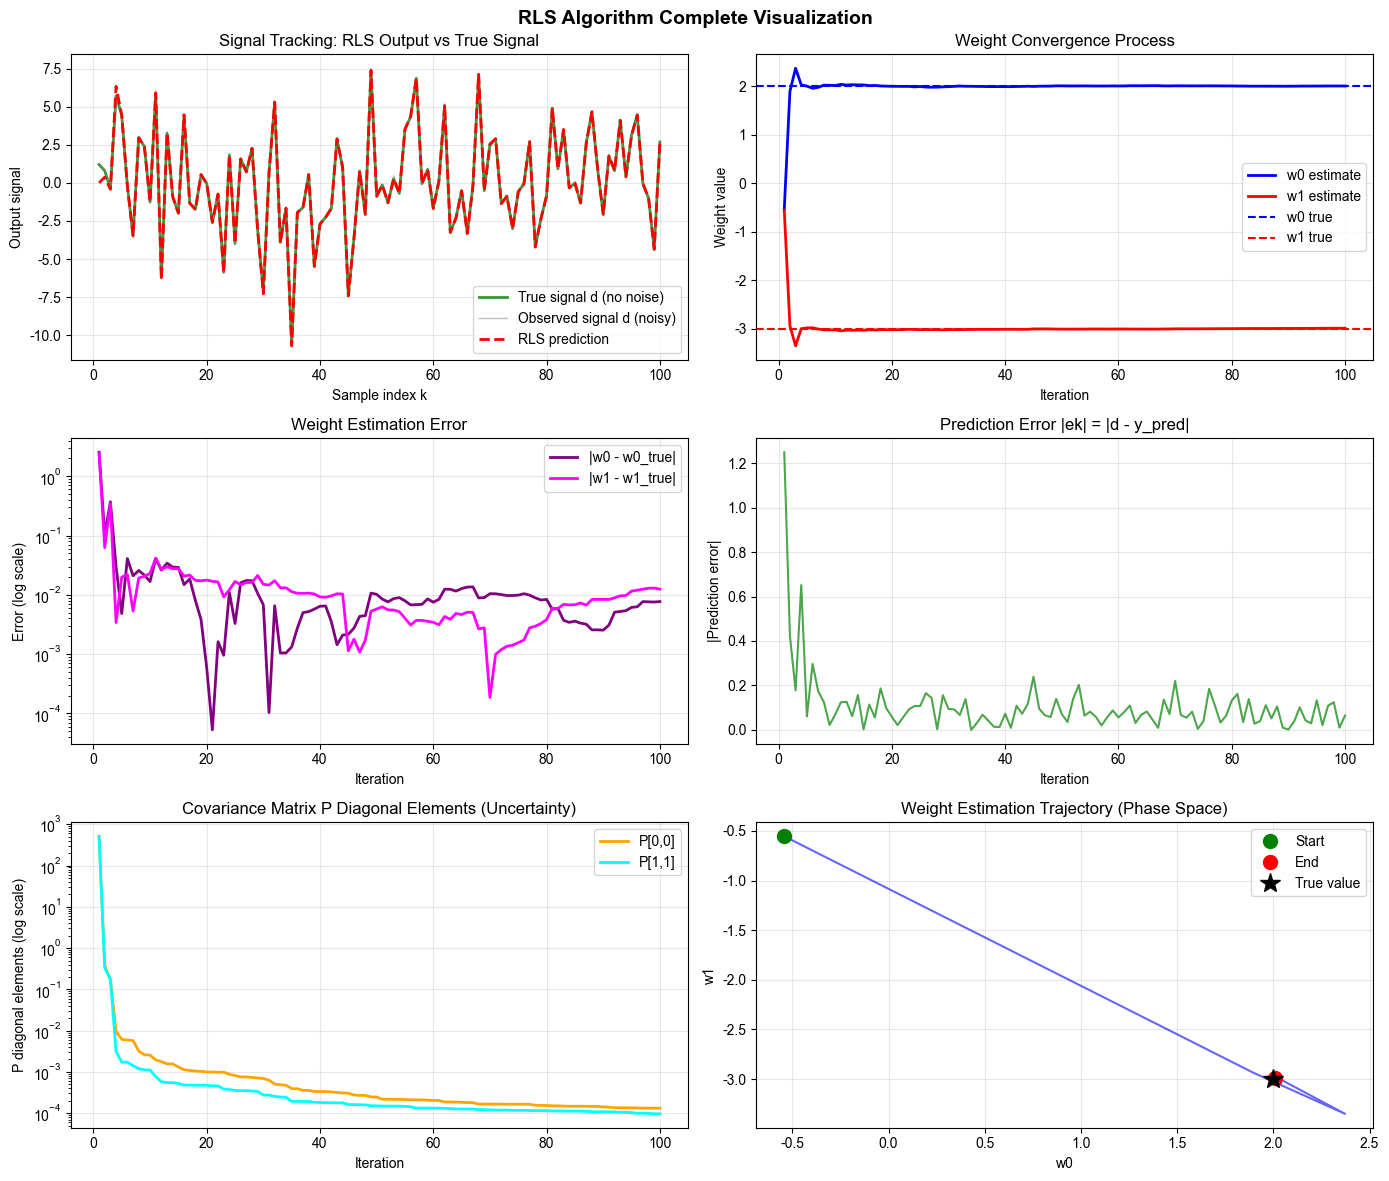

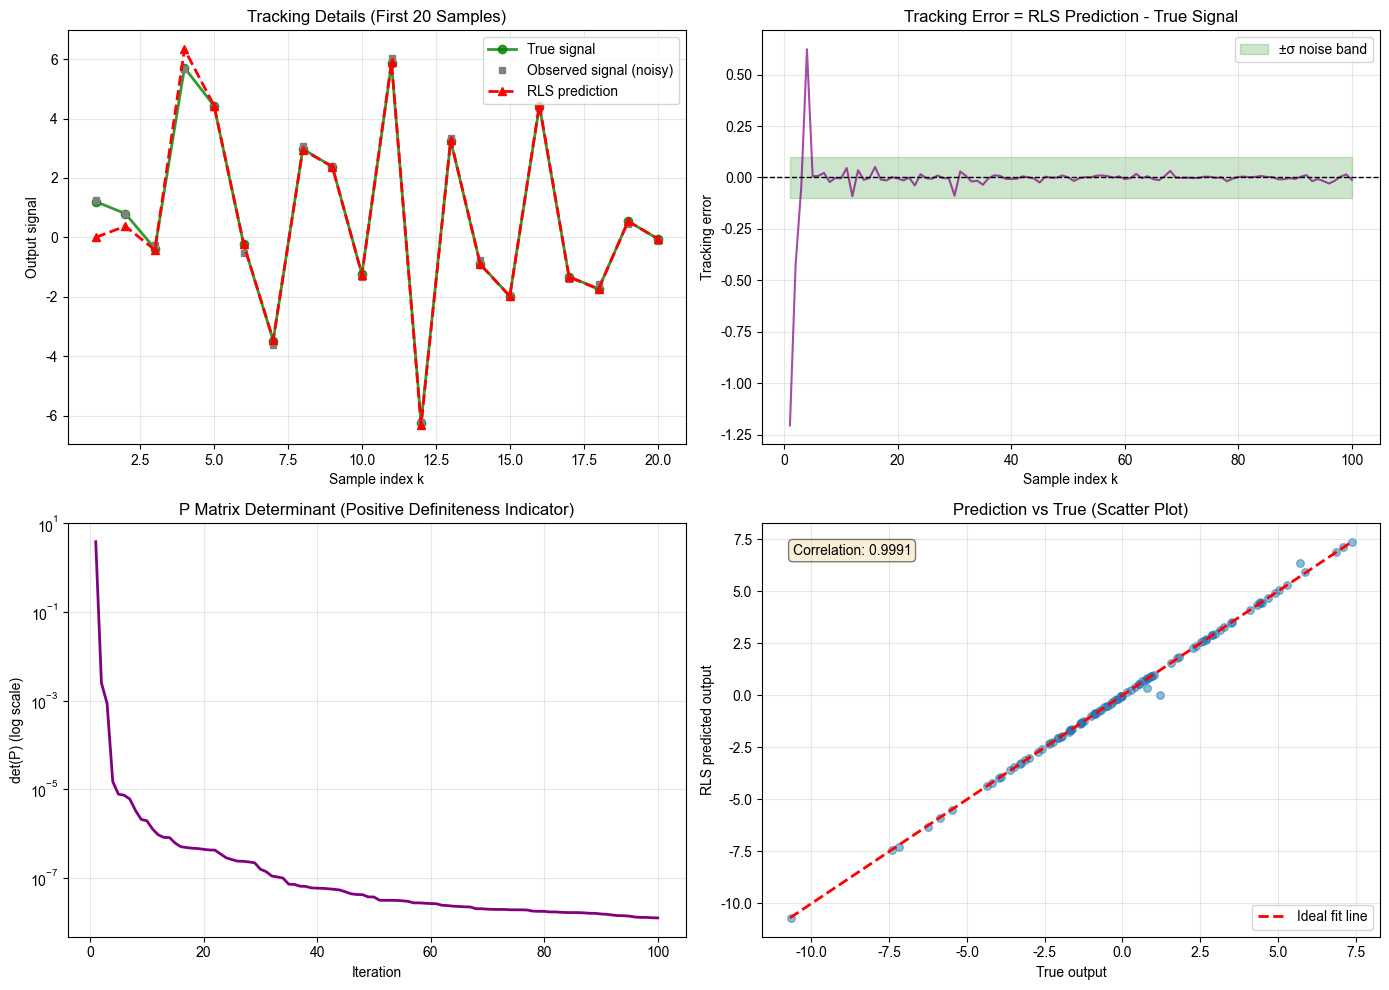


Comparison Experiment: Standard Form vs Joseph Form

Standard form - Final weights: [2.0077247619628906, -2.987506151199341]
Standard form - det(P): 1.226665e-08
Standard form - P symmetry error: 1.697810e-10

Joseph form - Final weights: [2.0077154636383057, -2.9875121116638184]
Joseph form - det(P): 1.226359e-08
Joseph form - P symmetry error: 1.517739e-10


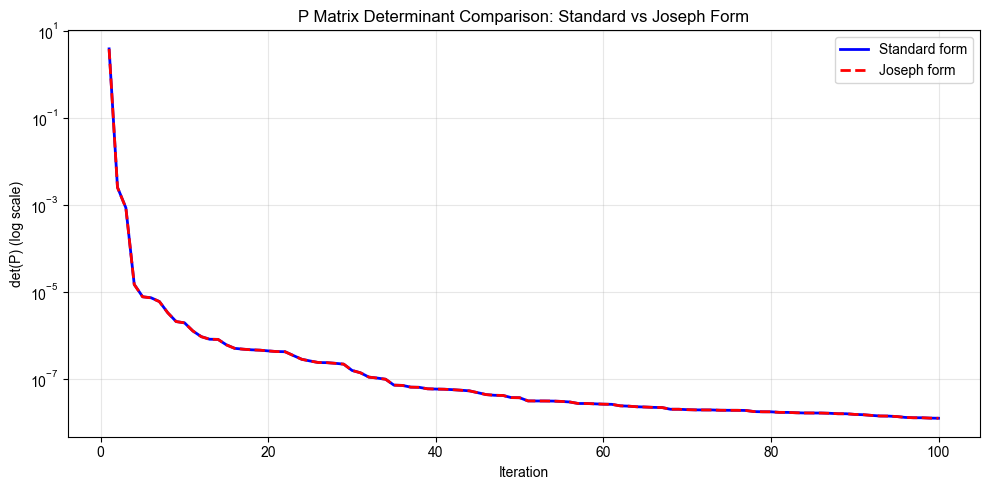


Visualization complete!


In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 10

# Set random seed
torch.manual_seed(0)

# ==================== Parameters ====================
num_samples = 100
input_dim = 2
sigma_n = 0.1  # Noise standard deviation
use_joseph = True  # Use Joseph form or not

# True system parameters
w_true = torch.tensor([[2.0], [-3.0]])

# ==================== Data Generation ====================
# Generate input x_k
X = torch.randn(num_samples, input_dim, 1)

# Generate true output (without noise)
d_true = torch.zeros(num_samples, 1)
for i in range(num_samples):
    d_true[i] = torch.matmul(X[i].t(), w_true)

# Generate noisy observation output
noise = sigma_n * torch.randn(num_samples, 1)
d = d_true + noise

# ==================== RLS Initialization ====================
w = torch.zeros((input_dim, 1))
P = 1000 * torch.eye(input_dim)  # Large initial value for high uncertainty
I = torch.eye(input_dim)

# Recording variables
w_estimates = []
w0_errors = []
w1_errors = []
prediction_errors = []
predictions = []  # Predicted output
P_determinants = []
P_00_values = []
P_11_values = []

# ==================== RLS Main Loop ====================
print(f"Running RLS algorithm ({'Joseph form' if use_joseph else 'Standard form'})...")
print(f"True weights: w_true = {w_true.squeeze().tolist()}")

for k in range(num_samples):
    x_k = X[k]          # (2, 1)
    d_k = d[k]          # (1,)
    
    # Predict output (before update)
    y_pred = torch.matmul(x_k.t(), w)
    predictions.append(y_pred.item())
    
    # 1. Calculate optimal learning gain g_k
    Px = torch.matmul(P, x_k)  # (2, 1)
    denominator = torch.matmul(x_k.t(), Px) + sigma_n**2  # Scalar
    g_k = Px / denominator  # (2, 1)
    
    # 2. Update weights
    e_k = d_k - torch.matmul(x_k.t(), w)  # Prediction error
    w = w + g_k * e_k
    
    # 3. Update covariance matrix P
    if use_joseph:
        # Joseph form (numerically stable)
        I_gx = I - torch.matmul(g_k, x_k.t())
        P = torch.matmul(torch.matmul(I_gx, P), I_gx.t()) + \
            sigma_n**2 * torch.matmul(g_k, g_k.t())
    else:
        # Standard form
        P = P - torch.matmul(g_k, torch.matmul(x_k.t(), P))
    
    # 4. Record results
    w_estimates.append(w.clone())
    w0_errors.append(torch.abs(w[0, 0] - w_true[0, 0]).item())
    w1_errors.append(torch.abs(w[1, 0] - w_true[1, 0]).item())
    prediction_errors.append(torch.abs(e_k).item())
    P_determinants.append(torch.det(P).item())
    P_00_values.append(P[0, 0].item())
    P_11_values.append(P[1, 1].item())

# Convert to numpy arrays for plotting
w_estimates = torch.stack(w_estimates, dim=0).squeeze().numpy()
iterations = np.arange(1, num_samples + 1)
d_true_np = d_true.squeeze().numpy()
d_noisy_np = d.squeeze().numpy()
predictions_np = np.array(predictions)

# ==================== Print Results ====================
print(f"\nFinal estimated weights: w = {w.squeeze().tolist()}")
print(f"Estimation error: Δw0 = {w0_errors[-1]:.6f}, Δw1 = {w1_errors[-1]:.6f}")
print(f"Final P matrix determinant: det(P) = {P_determinants[-1]:.6e}")
print(f"P matrix remains positive definite: {P_determinants[-1] > 0}")

# ==================== Main Visualization (3x2 grid) ====================
fig = plt.figure(figsize=(14, 12))

# Subplot 1: Signal Tracking ★★★ NEW ★★★
ax1 = plt.subplot(3, 2, 1)
ax1.plot(iterations, d_true_np, 'g-', linewidth=2, label='True signal d (no noise)', alpha=0.8)
ax1.plot(iterations, d_noisy_np, 'gray', linewidth=1, alpha=0.5, label='Observed signal d (noisy)')
ax1.plot(iterations, predictions_np, 'r--', linewidth=2, label='RLS prediction')
ax1.set_xlabel('Sample index k')
ax1.set_ylabel('Output signal')
ax1.set_title('Signal Tracking: RLS Output vs True Signal')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: Weight Convergence
ax2 = plt.subplot(3, 2, 2)
ax2.plot(iterations, w_estimates[:, 0], 'b-', linewidth=2, label='w0 estimate')
ax2.plot(iterations, w_estimates[:, 1], 'r-', linewidth=2, label='w1 estimate')
ax2.axhline(y=w_true[0, 0].item(), color='b', linestyle='--', linewidth=1.5, label='w0 true')
ax2.axhline(y=w_true[1, 0].item(), color='r', linestyle='--', linewidth=1.5, label='w1 true')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Weight value')
ax2.set_title('Weight Convergence Process')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Estimation Error (log scale)
ax3 = plt.subplot(3, 2, 3)
ax3.semilogy(iterations, w0_errors, 'purple', linewidth=2, label='|w0 - w0_true|')
ax3.semilogy(iterations, w1_errors, 'magenta', linewidth=2, label='|w1 - w1_true|')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Error (log scale)')
ax3.set_title('Weight Estimation Error')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Subplot 4: Prediction Error
ax4 = plt.subplot(3, 2, 4)
ax4.plot(iterations, prediction_errors, 'g-', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('|Prediction error|')
ax4.set_title('Prediction Error |ek| = |d - y_pred|')
ax4.grid(True, alpha=0.3)

# Subplot 5: P Matrix Diagonal Elements (Uncertainty)
ax5 = plt.subplot(3, 2, 5)
ax5.semilogy(iterations, P_00_values, 'orange', linewidth=2, label='P[0,0]')
ax5.semilogy(iterations, P_11_values, 'cyan', linewidth=2, label='P[1,1]')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('P diagonal elements (log scale)')
ax5.set_title('Covariance Matrix P Diagonal Elements (Uncertainty)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Subplot 6: Weight Trajectory (Phase Space)
ax6 = plt.subplot(3, 2, 6)
ax6.plot(w_estimates[:, 0], w_estimates[:, 1], 'b-', linewidth=1.5, alpha=0.6)
ax6.plot(w_estimates[0, 0], w_estimates[0, 1], 'go', markersize=10, label='Start')
ax6.plot(w_estimates[-1, 0], w_estimates[-1, 1], 'ro', markersize=10, label='End')
ax6.plot(w_true[0, 0].item(), w_true[1, 0].item(), 'k*', markersize=15, label='True value')
ax6.set_xlabel('w0')
ax6.set_ylabel('w1')
ax6.set_title('Weight Estimation Trajectory (Phase Space)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle(f'RLS Algorithm Complete Visualization', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== Additional Analysis: Signal Tracking Details ====================
fig2 = plt.figure(figsize=(14, 10))

# Subplot 1: Signal Tracking Details (First 20 samples)
ax7 = plt.subplot(2, 2, 1)
n_zoom = 20
ax7.plot(range(1, n_zoom+1), d_true_np[:n_zoom], 'go-', linewidth=2, 
         markersize=6, label='True signal', alpha=0.8)
ax7.plot(range(1, n_zoom+1), d_noisy_np[:n_zoom], 's', color='gray', 
         markersize=4, label='Observed signal (noisy)')
ax7.plot(range(1, n_zoom+1), predictions_np[:n_zoom], 'r^--', linewidth=2, 
         markersize=6, label='RLS prediction')
ax7.set_xlabel('Sample index k')
ax7.set_ylabel('Output signal')
ax7.set_title(f'Tracking Details (First {n_zoom} Samples)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Subplot 2: Tracking Error (Prediction - True)
ax8 = plt.subplot(2, 2, 2)
tracking_error = predictions_np - d_true_np
ax8.plot(iterations, tracking_error, 'purple', linewidth=1.5, alpha=0.7)
ax8.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax8.fill_between(iterations, -sigma_n, sigma_n, alpha=0.2, color='green', label='±σ noise band')
ax8.set_xlabel('Sample index k')
ax8.set_ylabel('Tracking error')
ax8.set_title('Tracking Error = RLS Prediction - True Signal')
ax8.legend()
ax8.grid(True, alpha=0.3)

# Subplot 3: P Matrix Determinant
ax9 = plt.subplot(2, 2, 3)
ax9.semilogy(iterations, P_determinants, 'purple', linewidth=2)
ax9.set_xlabel('Iteration')
ax9.set_ylabel('det(P) (log scale)')
ax9.set_title('P Matrix Determinant (Positive Definiteness Indicator)')
ax9.grid(True, alpha=0.3)

# Subplot 4: Scatter Plot - Prediction vs True
ax10 = plt.subplot(2, 2, 4)
ax10.scatter(d_true_np, predictions_np, alpha=0.5, s=30)
# Ideal line y=x
min_val = min(d_true_np.min(), predictions_np.min())
max_val = max(d_true_np.max(), predictions_np.max())
ax10.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal fit line')
ax10.set_xlabel('True output')
ax10.set_ylabel('RLS predicted output')
ax10.set_title('Prediction vs True (Scatter Plot)')
ax10.legend()
ax10.grid(True, alpha=0.3)
# Calculate correlation coefficient
correlation = np.corrcoef(d_true_np, predictions_np)[0, 1]
ax10.text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
         transform=ax10.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==================== Comparison: Standard vs Joseph Form ====================
print("\n" + "="*60)
print("Comparison Experiment: Standard Form vs Joseph Form")
print("="*60)

def run_rls_comparison(num_samples, use_joseph_form):
    """Run RLS algorithm and return final results"""
    torch.manual_seed(0)
    
    # Generate same data
    X = torch.randn(num_samples, input_dim, 1)
    d = torch.zeros(num_samples, 1)
    for i in range(num_samples):
        d[i] = torch.matmul(X[i].t(), w_true)
    d = d + sigma_n * torch.randn(num_samples, 1)
    
    # Initialize
    w = torch.zeros((input_dim, 1))
    P = 1000 * torch.eye(input_dim)
    I = torch.eye(input_dim)
    
    P_dets = []
    
    # RLS loop
    for k in range(num_samples):
        x_k = X[k]
        d_k = d[k]
        
        Px = torch.matmul(P, x_k)
        denominator = torch.matmul(x_k.t(), Px) + sigma_n**2
        g_k = Px / denominator
        
        e_k = d_k - torch.matmul(x_k.t(), w)
        w = w + g_k * e_k
        
        if use_joseph_form:
            I_gx = I - torch.matmul(g_k, x_k.t())
            P = torch.matmul(torch.matmul(I_gx, P), I_gx.t()) + \
                sigma_n**2 * torch.matmul(g_k, g_k.t())
        else:
            P = P - torch.matmul(g_k, torch.matmul(x_k.t(), P))
        
        P_dets.append(torch.det(P).item())
    
    return w, P, P_dets

# Run both methods
w_standard, P_standard, dets_standard = run_rls_comparison(num_samples, False)
w_joseph, P_joseph, dets_joseph = run_rls_comparison(num_samples, True)

print(f"\nStandard form - Final weights: {w_standard.squeeze().tolist()}")
print(f"Standard form - det(P): {torch.det(P_standard).item():.6e}")
print(f"Standard form - P symmetry error: {torch.norm(P_standard - P_standard.t()).item():.6e}")

print(f"\nJoseph form - Final weights: {w_joseph.squeeze().tolist()}")
print(f"Joseph form - det(P): {torch.det(P_joseph).item():.6e}")
print(f"Joseph form - P symmetry error: {torch.norm(P_joseph - P_joseph.t()).item():.6e}")

# Plot comparison
fig3 = plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1)
ax.semilogy(iterations, dets_standard, 'b-', linewidth=2, label='Standard form')
ax.semilogy(iterations, dets_joseph, 'r--', linewidth=2, label='Joseph form')
ax.set_xlabel('Iteration')
ax.set_ylabel('det(P) (log scale)')
ax.set_title('P Matrix Determinant Comparison: Standard vs Joseph Form')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")